## this will be intended to be very similar to validate_eq5.

- load the Gates and the TS diagrams from the J terms
- create the diverence of the J terms to show warming
- load a plot of the residual vs the binwidth (bigger should be less residual) for T and for S

In [1]:
# auto-reload edited modules
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, "/home/mmurakami/crios_backups/an_helper_functions")

# run the script into the curre nt kernel (vars/functions become available)
%run -i "/home/mmurakami/crios_backups/an_helper_functions/prep_grid_aste_90.py"

(450, 90)
RAC2d (40500,)
(100,)


In [2]:
dirroot = "/scratch3/atnguyen/aste_90x150x60/"
dirgrid = dirroot + "GRID_real8/"
dirgridnb = dirroot + "GRID_noblank/"
runstr= "run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/"
layers_path = dirroot + runstr
extL = "LAYERS"
dirmask = dirroot + "run_template/input_maskTransport/"
dirbudg = layers_path + "diags/BUDG/"
dirdiags = dirbudg
dirstate = layers_path + "diags/STATE/"
dirlayers = layers_path + "diags/LAYERS/"
dirtrsp = layers_path + "diags/TRSP/"

In [3]:
# try to use rdmds
fileprefix = "/scratch3/atnguyen/aste_90x150x60/"
extBasin='run_template/input_maskTransport/'
filename = fileprefix + extBasin + "GATE_transports_v2_mskBasin.bin"
ind = np.fromfile(filename, dtype=np.int32)  # auto-reads .meta for shape/dtype/order
orig_shape = (ind.shape)

ind2d = ind.reshape(ny,nx)

mymsk = np.full((ny,nx),np.nan)
mymsk[ind2d == 57408.0] = 1

# make this smaller
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan

ind = ind.reshape(ny,nx)
mymsk = np.full((ny,nx),np.nan)
mymsk[ind == 57408.0] = 1

# make this smaller
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan

In [4]:
# --- Load original edges to get bounds only ---
_T_edges_raw = rdmds(layers_path + "layers2TH").reshape(-1)
_S_edges_raw = rdmds(layers_path + "layers1SLT").reshape(-1)

# --- Define bin count and recompute uniform edges ---
# adding a number of bins here will allow us to perform the limit for small/large nT or nS
nT = 70
nS = 70

# nT = 150
# nS = 150

T_edges = np.linspace(_T_edges_raw[0], _T_edges_raw[-1], nT + 1)                             # boundsT
S_edges = np.linspace(_S_edges_raw[0], _S_edges_raw[-1], nS + 1)                             # boundsS

# --- Everything else derived programmatically ---
T_centers      = 0.5 * (T_edges[:-1] + T_edges[1:])                                          # binmidT, binsTH_centers
S_centers      = 0.5 * (S_edges[:-1] + S_edges[1:])                                          # binmidS, binsSLT_centers
binmidT = T_centers
binmidS = S_centers

dT_edges       = T_edges[1:] - T_edges[:-1]                                                  # binwidthT
dS_edges       = S_edges[1:] - S_edges[:-1]                                                  # binwidthS

# these are the points we normalize for the J term --  i
dT_centers     = 0.5 * (dT_edges[:-1] + dT_edges[1:])                                        # binwidthT1
dS_centers     = 0.5 * (dS_edges[:-1] + dS_edges[1:])                                        # binwidthS1
binwidthT1 = dT_centers
binwidthS1 = dS_centers

T_inner_edges  = T_edges[1:-1]                                                               # binmidTp
S_inner_edges  = S_edges[1:-1]                                                               # binmidSp

T_edges_2d,       S_edges_2d       = np.meshgrid(T_edges,       S_edges)
T_centers_2d,     S_centers_2d     = np.meshgrid(T_centers,     S_centers)
T_inner_edges_2d, S_inner_edges_2d = np.meshgrid(T_inner_edges, S_inner_edges)

dT_3d, dS_3d = np.meshgrid(dT_edges, dS_edges)
dT_3d = dT_3d.reshape(nS, nT, 1)
dS_3d = dS_3d.reshape(nS, nT, 1)

# set the mesh for plotting
binmidTp = T_edges[1:-1]
binmidSp = S_edges[1:-1]
Tbin2,Sbin2 = np.meshgrid(binmidTp,binmidSp) # for plotting the J terms individually as vectors!
bincentTp = T_centers[1:-1]
bincentSp = S_centers[1:-1]
Tbin3,Sbin3 = np.meshgrid(bincentTp,bincentSp) # for plotting the convergence of the J vectors

## load the same as before for the full Barents Sea and for the gates

In [12]:
# this should be the correct version of mymsk, and then we just need the Msum terms for T and S
tsstr = np.array(["0000000003","0000000004"])
t2 = int(tsstr[1]) # for the offline version

In [26]:
from create_aste90_layers import create_layers_totalTHETA,create_layers_totalSALT

# note 3/9 -- we should allow these functions to take the boundsT or T_edges

dt = 1800
# load the convergence terms in degC.m^3/s and PSU.m^3/s
termsT3D = create_layers_totalTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,T_edges,S_edges,mapping=True)
termsS3D = create_layers_totalSALT(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,T_edges,S_edges,mapping=True)

# load the gateway dictionaries in deg.m^3/s and PSU.m^3/s
# I actually don't think this is how we want to do this because this is just a 1D array
MsumT,dF_Tnew = create_layers_totalTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,T_edges,S_edges,mapping=False)
MsumS,dF_Snew = create_layers_totalSALT(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,T_edges,S_edges,mapping=False)

In [27]:
# do a validation check here that Msum is the same as the total (nansum of termsT3D and termsS3D)
print(np.nansum(MsumT['Msum']),"degC.m^3/s")
print(np.nansum(termsT3D['ADVh'] * np.tile(mymsk[np.newaxis,:,:],(nz,1,1))),"degC.m^3/s")
print(np.nansum(dF_Tnew[0]),"degC.m^3/s")
print(np.nansum(MsumT["Msum_TSnn"]),"degC.m^3/s")


print()

print(np.nansum(MsumS['Msum']),"PSU.m^3/s")
print(np.nansum(termsS3D['ADVh'] * np.tile(mymsk[np.newaxis,:,:],(nz,1,1))),"PSU.m^3/s")
print(np.nansum(dF_Snew[0]),"PSU.m^3/s")
print(np.nansum(MsumS["Msum_TSnn"]),"PSU.m^3/s")

11126757.315022953 degC.m^3/s
11126757.315022955 degC.m^3/s
11126757.315022955 degC.m^3/s
11126757.315022955 degC.m^3/s

-4392889.650053522 PSU.m^3/s
-4392889.650053502 PSU.m^3/s
-4392889.650053497 PSU.m^3/s
-4392889.650053486 PSU.m^3/s


In [28]:
# get the THETA as a time average
t2 = int(tsstr[1])
file_name = "state_3d_set1"
meta_state_3d_set1 = parsemeta(dirstate + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_state_3d_set1["fldList"])
varnames = np.array(["THETA","SALT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
THETA,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[0])
SALT,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[1])

THETA = THETA.reshape(nz, ny, nx)
SALT  = SALT.reshape(nz, ny, nx)

In [29]:
# great, we have now validated the heat transport through the gates, now we can load the TS diagrams
# we can use termsT3D and termsS3D

def bin_3d_term_to_TS(term3d, THETA, SALT, mymsk3d, binmidT, binmidS, binwidthT1, binwidthS1):
    nT = len(binmidT)
    nS = len(binmidS)

    dF_TS = np.zeros((nT-1, nS-1), dtype=float)
    L_TS  = np.zeros((nT-1, nS-1), dtype=int)

    # Flatten
    T_flat = np.ravel(THETA * mymsk3d, order="F")
    S_flat = np.ravel(SALT  * mymsk3d, order="F")
    X_flat = np.ravel(term3d * mymsk3d, order="F")

    # Bin indices
    iT = np.searchsorted(binmidT, T_flat, side="right") - 1
    iS = np.searchsorted(binmidS, S_flat, side="right") - 1

    # Valid points
    ok = (iT >= 0) & (iT < nT-1) & (iS >= 0) & (iS < nS-1) & np.isfinite(X_flat)
    iT = iT[ok]
    iS = iS[ok]
    vals = X_flat[ok]

    # Accumulate
    np.add.at(dF_TS, (iT, iS), vals)
    np.add.at(L_TS,  (iT, iS), 1)

    # Normalize by both bin widths
    dA = binwidthT1[:, None] * binwidthS1[None, :]  # An suggests doing this separately in future
                                                    # first division in dT or dS gets you G_T or G_S
                                                    # second division by dS or dT gets you the J component of J_S or J_T
    G_TS = dF_TS / dA                               # should not be called G_TS here!

    return G_TS, dF_TS, L_TS

termsT_TS = {}   # inputs as degC.m^3/s, out as m^3/s/PSU, same as layers Jy
mymsk3d = np.tile(mymsk[np.newaxis,:,:],(nz,1,1))
for k, arr3d in termsT3D.items():
    termsT_TS[k], _, _ = bin_3d_term_to_TS(
        arr3d, THETA, SALT, mymsk3d,
        T_centers, S_centers, dT_centers, dS_centers
    )

termsS_TS = {}   # inputs as PSU.m^3/s, out as m^3/s/degC, same as layers Jx
for k, arr3d in termsS3D.items():
    termsS_TS[k], _, _ = bin_3d_term_to_TS(
        arr3d, THETA, SALT, mymsk3d,
        T_centers, S_centers, dT_centers, dS_centers
    )

In [30]:
# the TS binning is wrong for this version, I think I will fix at home

In [31]:
# we can define M_T and M_S here from the MsumT and MsumS

M_T = MsumT["Msum_TS"]
M_S = MsumS["Msum_TS"]
# M_T.shape

In [36]:
# great, now load the function for divergence


def get_div(Jy, Jx, dT_edges, dS_edges,ffac=1e-6):
    '''
    inputs:
        Jy: transport in T direction, shape (nT-1, nS-1), units of m^3/s/PSU
        Jx: transport in S direction, shape (nT-1, nS-1), units of m^3/s/degC
        dT_edges: T-bin widths for interior T differences, shape (nT-2,)
        dS_edges: S-bin widths for interior S differences, shape (nS-2,)
        ffac: the 1e-6 to get to Sv from previously (will remind us to use this here)

    outputs:
        gradJ: divergence on interior cell centers, shape (nT-2, nS-2), units of Sv/PSU/degC
    '''

    # Difference in T direction: shape (nT-2, nS-1)
    dJy = Jy[1:, :] - Jy[:-1, :]            # m^3/s/PSU

    # Difference in S direction: shape (nT-1, nS-2)
    dJx = Jx[:, 1:] - Jx[:, :-1]            # m^3/s/degC

    # Divide by bin widths
    # dT_edges[:, None] broadcasts across S
    dJydT = dJy / dT_edges[1:-1, None]      # (nT-2, nS-1);  m^3/s/PSU -->   m^3/s/PSU/degC

    # dS_edges[None, :] broadcasts across T
    dJxdS = dJx / dS_edges[None, 1:-1]      # (nT-1, nS-2);  m^3/s/degC -->  m^3/s/degC/PSU

    # Center to common interior points (nT-2, nS-2)
    dJydT_center = 0.5 * (dJydT[:, 1:] + dJydT[:, :-1])
    dJxdS_center = 0.5 * (dJxdS[1:, :] + dJxdS[:-1, :])

    gradJ = -(dJydT_center + dJxdS_center)                # we set so that + is creation

    return gradJ * ffac                                   # Sv/PSU/degC

In [37]:
T_keys = list(termsT_TS.keys())
S_keys = list(termsS_TS.keys())

# total tendency
dVdt = get_div(termsT_TS['tend'], termsS_TS['tend'], dT_edges, dS_edges)

# example single term
divADVh = get_div(termsT_TS['ADVh'], termsS_TS['ADVh'], dT_edges, dS_edges)

# internal = sum of terms at positions 1,2,3,5
internal_inds = [1, 2, 3, 5]

divint = sum(
    get_div(termsT_TS[T_keys[i]], termsS_TS[S_keys[i]], dT_edges, dS_edges)
    for i in internal_inds
)

# surface = term at position 4
surface_ind = 4
divsurf = get_div(
    termsT_TS[T_keys[surface_ind]],
    termsS_TS[S_keys[surface_ind]],
    dT_edges,
    dS_edges
)

div_gates = get_div(M_T,M_S,dT_edges,dS_edges)

(-2.0, 10.0)

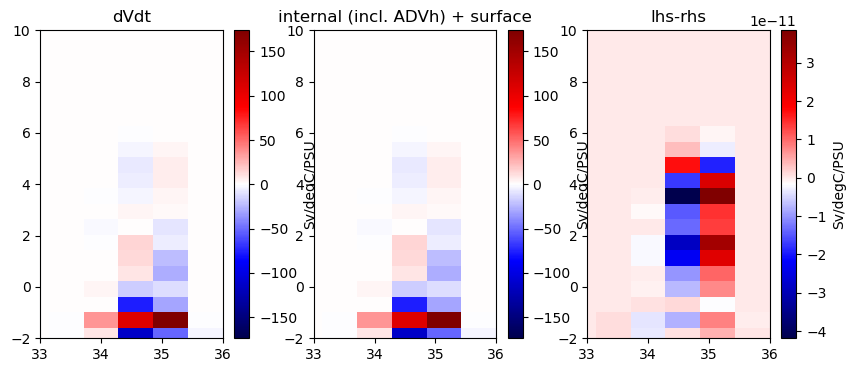

In [42]:
# great, now plot as we did in the previous file

fig = plt.figure()

# plot each of the above and a sum of them

ax = plt.subplot(131)
lhs = dVdt
vlev = np.nanmax(lhs)
cb = ax.pcolormesh(Sbin3,Tbin3,dVdt.T,cmap='seismic',vmin=-vlev,vmax=vlev)
ax.set_title("dVdt")
plt.colorbar(cb,label="Sv/degC/PSU")
ax.set_xlim(33,36)
ax.set_ylim(-2,10)

ax = plt.subplot(132)
rhs = divADVh + divint + divsurf
ax.set_title("internal (incl. ADVh) + surface")
cb = ax.pcolormesh(Sbin3,Tbin3,rhs.T,cmap='seismic',vmin=-vlev,vmax=vlev)
plt.colorbar(cb,label="Sv/degC/PSU")
ax.set_xlim(33,36)
ax.set_ylim(-2,10)

ax = plt.subplot(133)
ax.set_title("lhs-rhs")
cb = ax.pcolormesh(Sbin3,Tbin3,(rhs-lhs).T,cmap='seismic')
plt.colorbar(cb,label="Sv/degC/PSU")
ax.set_xlim(33,36)
ax.set_ylim(-2,10)

Text(0.5, 0.98, 'Residual at dT=0.60 and dS=0.57')

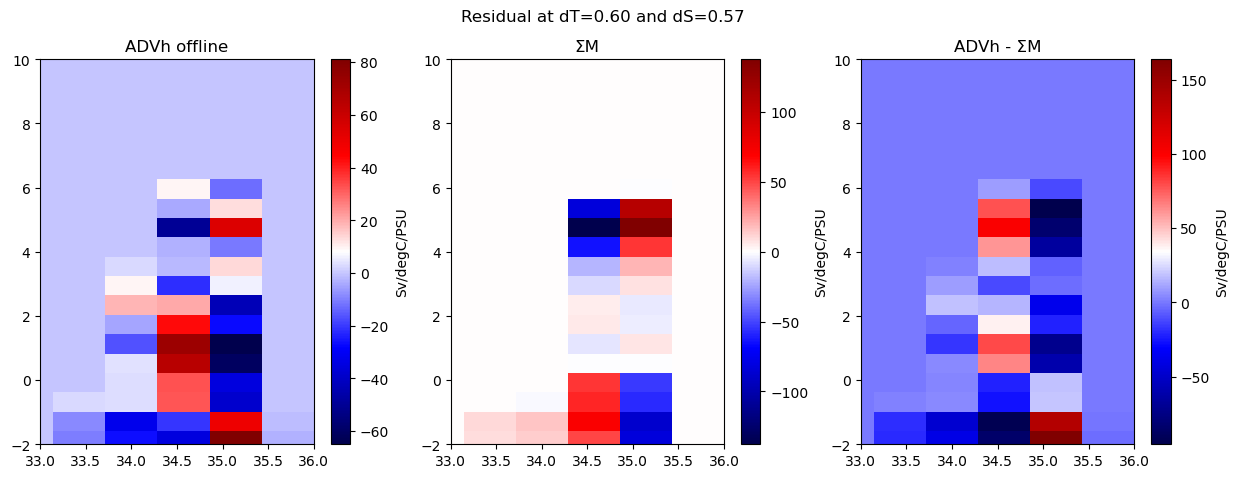

In [43]:
# now plot with the gates

# great, now look at the gateway term in TS as compared to the ADVh term
fig = plt.figure(figsize=(15,5))

# plot each of the above and a sum of them
ax = plt.subplot(131)
cb = ax.pcolormesh(Sbin3,Tbin3,divADVh.T,cmap='seismic')
ax.set_title("ADVh offline")
plt.colorbar(cb,label="Sv/degC/PSU")
ax.set_xlim(33,36)
ax.set_ylim(-2,10)

ax = plt.subplot(132)
vlev = np.nanmax(div_gates)
cb = ax.pcolormesh(Sbin3,Tbin3,div_gates.T,cmap='seismic',vmin=-vlev,vmax=vlev)
ax.set_title("ΣM")
plt.colorbar(cb,label="Sv/degC/PSU")
ax.set_xlim(33,36)
ax.set_ylim(-2,10)

ax = plt.subplot(133)
cb = ax.pcolormesh(Sbin3,Tbin3,(divADVh-div_gates).T,cmap='seismic')#,vmin=-3,vmax=3)
ax.set_title("ADVh - ΣM")
plt.colorbar(cb,label="Sv/degC/PSU")
ax.set_xlim(33,36)
ax.set_ylim(-2,10)

plt.suptitle(f"Residual at dT={dT_centers[0]:.2f} and dS={dS_centers[0]:.2f}")


In [44]:
print(np.nanmax((divADVh-div_gates)),"Sv/degC/PSU")
print(np.nanmin((divADVh-div_gates)),"Sv/degC/PSU") # yes because these are being binned to the same value

163.9670567918872 Sv/degC/PSU
-95.6622413042659 Sv/degC/PSU


## Great, now port this whole thing into a function that depends on the boundsT and boundsS

In [53]:
# we can either read these from a file or just list them ourselves

def print_resid(T_edges,S_edges):
    
    dT_edges       = T_edges[1:] - T_edges[:-1]                                                  # binwidthT
    dS_edges       = S_edges[1:] - S_edges[:-1]                                                  # binwidthS
    # --- Everything else derived programmatically ---
    T_centers      = 0.5 * (T_edges[:-1] + T_edges[1:])                                          # binmidT, binsTH_centers
    S_centers      = 0.5 * (S_edges[:-1] + S_edges[1:])                                          # binmidS, binsSLT_centers
    binmidT = T_centers
    binmidS = S_centers
    
    dT_edges       = T_edges[1:] - T_edges[:-1]                                                  # binwidthT
    dS_edges       = S_edges[1:] - S_edges[:-1]                                                  # binwidthS
    
    # these are the points we normalize for the J term --  i
    dT_centers     = 0.5 * (dT_edges[:-1] + dT_edges[1:])                                        # binwidthT1
    dS_centers     = 0.5 * (dS_edges[:-1] + dS_edges[1:])                                        # binwidthS1
    binwidthT1 = dT_centers
    binwidthS1 = dS_centers
    
    T_inner_edges  = T_edges[1:-1]                                                               # binmidTp
    S_inner_edges  = S_edges[1:-1]                                                               # binmidSp

    dt = 1800
    # load the convergence terms in degC.m^3/s and PSU.m^3/s
    termsT3D = create_layers_totalTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,T_edges,S_edges,mapping=True)
    termsS3D = create_layers_totalSALT(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,T_edges,S_edges,mapping=True)
    
    # load the gateway dictionaries in deg.m^3/s and PSU.m^3/s
    # I actually don't think this is how we want to do this because this is just a 1D array
    MsumT,dF_Tnew = create_layers_totalTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,T_edges,S_edges,mapping=False)
    MsumS,dF_Snew = create_layers_totalSALT(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,T_edges,S_edges,mapping=False)
    
    # bin these terms
    termsT_TS = {}   # inputs as degC.m^3/s, out as m^3/s/PSU, same as layers Jy
    mymsk3d = np.tile(mymsk[np.newaxis,:,:],(nz,1,1))
    for k, arr3d in termsT3D.items():
        termsT_TS[k], _, _ = bin_3d_term_to_TS(
            arr3d, THETA, SALT, mymsk3d,
            T_centers, S_centers, dT_centers, dS_centers
        )
    
    termsS_TS = {}   # inputs as PSU.m^3/s, out as m^3/s/degC, same as layers Jx
    for k, arr3d in termsS3D.items():
        termsS_TS[k], _, _ = bin_3d_term_to_TS(
            arr3d, THETA, SALT, mymsk3d,
            T_centers, S_centers, dT_centers, dS_centers
        )

    M_T = MsumT["Msum_TS"]
    M_S = MsumS["Msum_TS"]

    T_keys = list(termsT_TS.keys())
    S_keys = list(termsS_TS.keys())
    
    # total tendency
    dVdt = get_div(termsT_TS['tend'], termsS_TS['tend'], dT_edges, dS_edges)
    
    # example single term
    divADVh = get_div(termsT_TS['ADVh'], termsS_TS['ADVh'], dT_edges, dS_edges)
    
    # internal = sum of terms at positions 1,2,3,5
    internal_inds = [1, 2, 3, 5]
    
    divint = sum(
        get_div(termsT_TS[T_keys[i]], termsS_TS[S_keys[i]], dT_edges, dS_edges)
        for i in internal_inds
    )
    
    # surface = term at position 4
    surface_ind = 4
    divsurf = get_div(
        termsT_TS[T_keys[surface_ind]],
        termsS_TS[S_keys[surface_ind]],
        dT_edges,
        dS_edges
    )
    
    div_gates = get_div(M_T,M_S,dT_edges,dS_edges)

    # print the residual between overall lhs and rhs with the gates
    lhs = dVdt
    rhs = divint + divsurf + div_gates
    resid = lhs - rhs

    # return this spread
    dT = T_edges[1] - T_edges[0]
    dS = S_edges[1] - S_edges[0]
    spread = np.nanmax(resid) - np.nanmin(resid)

    return dT, dS, spread
    
ntest = np.array([5,20,30,40,50,60,70,100,130,140,170,200,250,300])

results = []

for t in ntest:
    nT, nS = t, t

    T_edges = np.linspace(_T_edges_raw[0], _T_edges_raw[-1], nT + 1)
    S_edges = np.linspace(_S_edges_raw[0], _S_edges_raw[-1], nS + 1)

    results.append(print_resid(T_edges, S_edges))

results = np.array(results)   # columns: dT, dS, spread

dT_vals = results[:, 0]
dS_vals = results[:, 1]
spread_vals = results[:, 2]


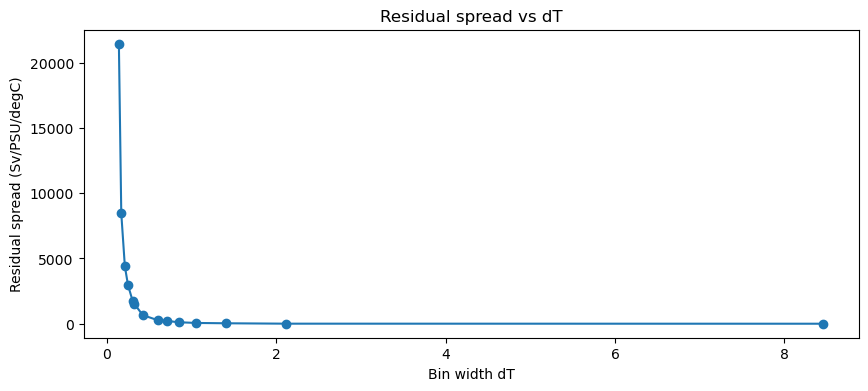

In [54]:
plt.figure()
plt.plot(dT_vals, spread_vals, 'o-')
plt.xlabel('Bin width dT')
plt.ylabel('Residual spread (Sv/PSU/degC)')
plt.title('Residual spread vs dT')
plt.show()

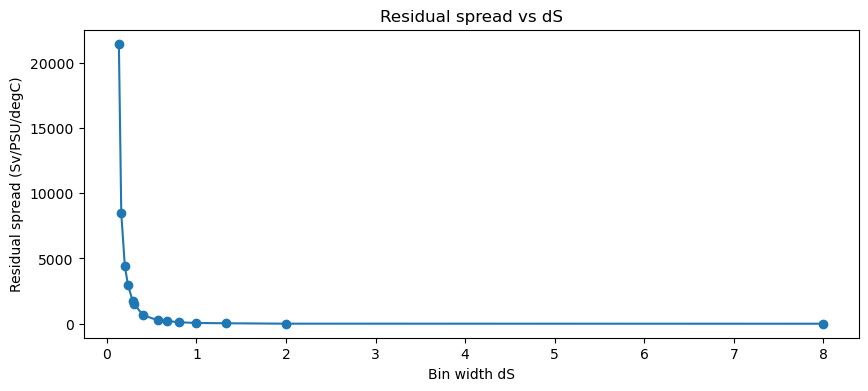

In [55]:
plt.figure()
plt.plot(dS_vals, spread_vals, 'o-')
plt.xlabel('Bin width dS')
plt.ylabel('Residual spread (Sv/PSU/degC)')
plt.title('Residual spread vs dS')
plt.show()